In [1]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [2]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    # smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # # Create smoothed version
            # ntwk_smooth = smooth_network(ntwk, window, poly)
            # ntwk_smooth.name = name

            # smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    # globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list

In [3]:
set_04_measured = load_directory(r'03_mar_meas_data', window=11, poly=3)

In [4]:
set_04_measured

[2-Port Network: 'S11_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S12_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S21_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S22_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S_Parameter_CS-5_GSG_150P_CPW_20um_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_17_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_18_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_19_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_20_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_21_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50

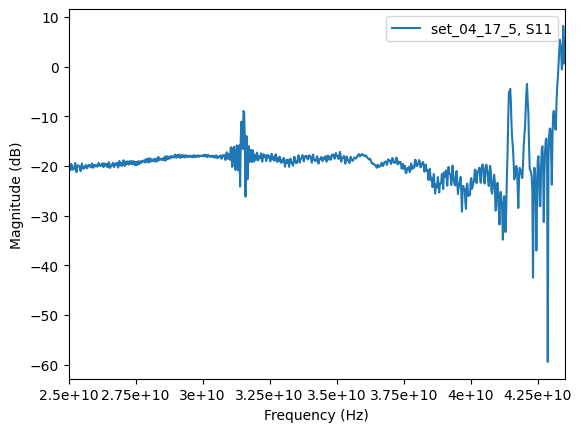

In [7]:
set_04_measured[5].plot_s_db(m=0,n=0)

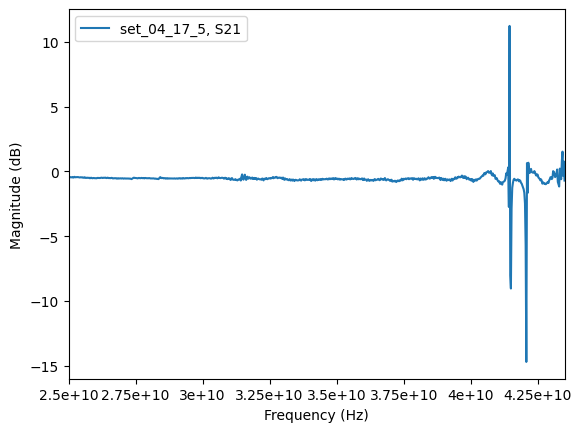

In [8]:
set_04_measured[5].plot_s_db(m=1,n=0)